In [9]:
# loading dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [14]:
import os
os.listdir()

['Untitled.ipynb',
 'Superstore.csv',
 'sales_forecasting.ipynb',
 '.ipynb_checkpoints']

In [15]:
df = pd.read_csv('Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [16]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [17]:
# converting Order Date to datetime so we can work with time series
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [18]:
# grouping sales by month to create time series data
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales = monthly_sales.to_timestamp()

monthly_sales.head()

Order Date
2014-01-01    14236.895
2014-02-01     4519.892
2014-03-01    55691.009
2014-04-01    28295.345
2014-05-01    23648.287
Freq: MS, Name: Sales, dtype: float64

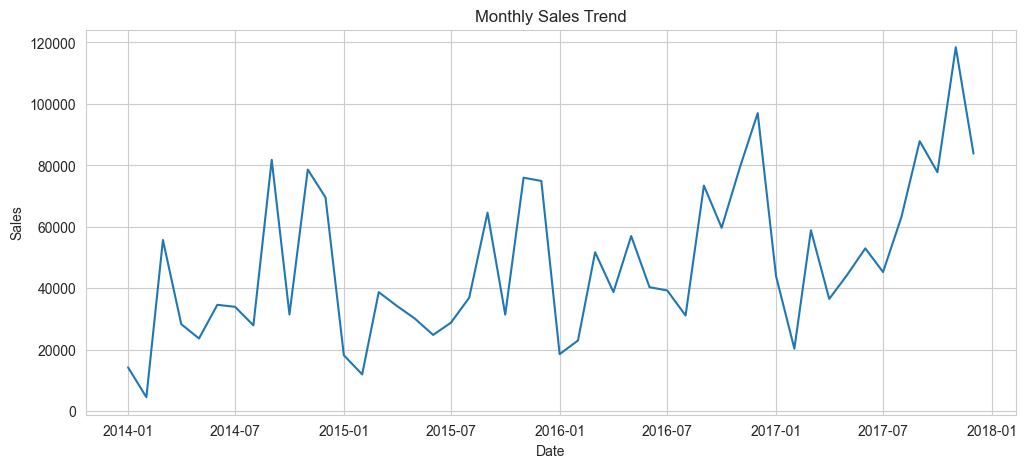

In [19]:
# plotting monthly sales to observe trend and patterns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_sales)
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [21]:
# ensuring consistent monthly frequency and filling missing values
monthly_sales = monthly_sales.asfreq('MS')
monthly_sales = monthly_sales.ffill()

In [22]:
# using exponential smoothing for basic forecasting
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(monthly_sales, trend='add', seasonal=None)
model_fit = model.fit()

In [23]:
# forecasting next 6 months
forecast = model_fit.forecast(6)

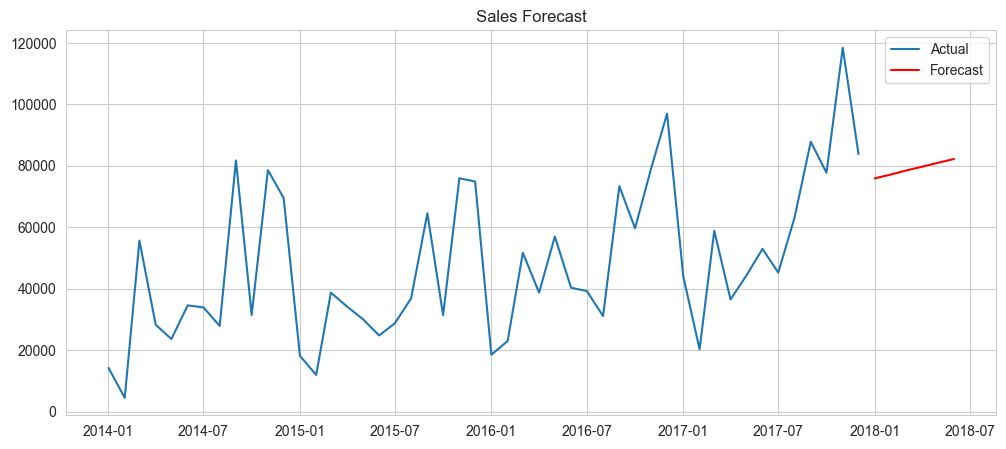

In [24]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales, label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.title("Sales Forecast")
plt.show()

In [25]:
print("""
Observations:
- Sales show an overall upward trend
- There are fluctuations indicating volatility
- No strong seasonality observed

Business Insight:
- Increasing trend suggests business growth
- Company should scale inventory accordingly
""")


Observations:
- Sales show an overall upward trend
- There are fluctuations indicating volatility
- No strong seasonality observed

Business Insight:
- Increasing trend suggests business growth
- Company should scale inventory accordingly



In [26]:
# splitting data into train and test to evaluate model performance
train = monthly_sales[:-6]
test = monthly_sales[-6:]

In [27]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(train, trend='add', seasonal=None)
model_fit = model.fit()

In [28]:
pred = model_fit.forecast(6)

In [29]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, pred))
print("RMSE:", rmse)

RMSE: 27780.885451245493


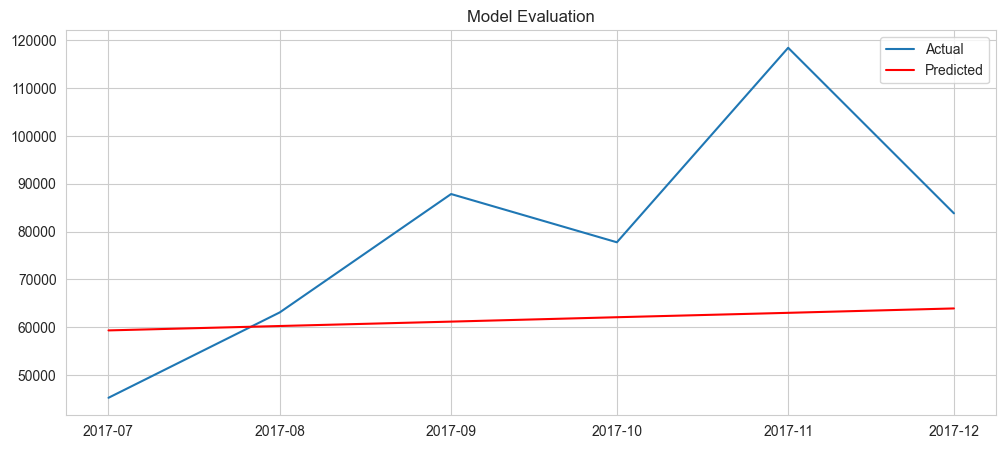

In [30]:
plt.figure(figsize=(12,5))
plt.plot(test, label='Actual')
plt.plot(pred, label='Predicted', color='red')
plt.legend()
plt.title("Model Evaluation")
plt.show()

In [31]:
print(f"""
Model Evaluation:
- RMSE: {rmse}

Interpretation:
- Lower RMSE indicates better prediction accuracy
- Model captures general trend but may miss fluctuations

Business Insight:
- Forecast is reliable for planning but not exact prediction
""")


Model Evaluation:
- RMSE: 27780.885451245493

Interpretation:
- Lower RMSE indicates better prediction accuracy
- Model captures general trend but may miss fluctuations

Business Insight:
- Forecast is reliable for planning but not exact prediction



In [32]:
model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)
model_fit = model.fit()

In [33]:
pred = model_fit.forecast(6)

In [34]:
print(f"""
Model Evaluation:
- RMSE: {rmse:.2f}

Interpretation:
- Model captures overall upward trend but underestimates sharp spikes
- High RMSE indicates model struggles with volatility

Business Insight:
- Sales show growth but are inconsistent
- Company should:
  1. Improve demand forecasting during peak months
  2. Investigate causes of sudden spikes (promotions, seasonality)
  3. Avoid over-reliance on simple forecasting models
""")


Model Evaluation:
- RMSE: 27780.89

Interpretation:
- Model captures overall upward trend but underestimates sharp spikes
- High RMSE indicates model struggles with volatility

Business Insight:
- Sales show growth but are inconsistent
- Company should:
  1. Improve demand forecasting during peak months
  2. Investigate causes of sudden spikes (promotions, seasonality)
  3. Avoid over-reliance on simple forecasting models



In [35]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train, order=(1,1,1))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(6)

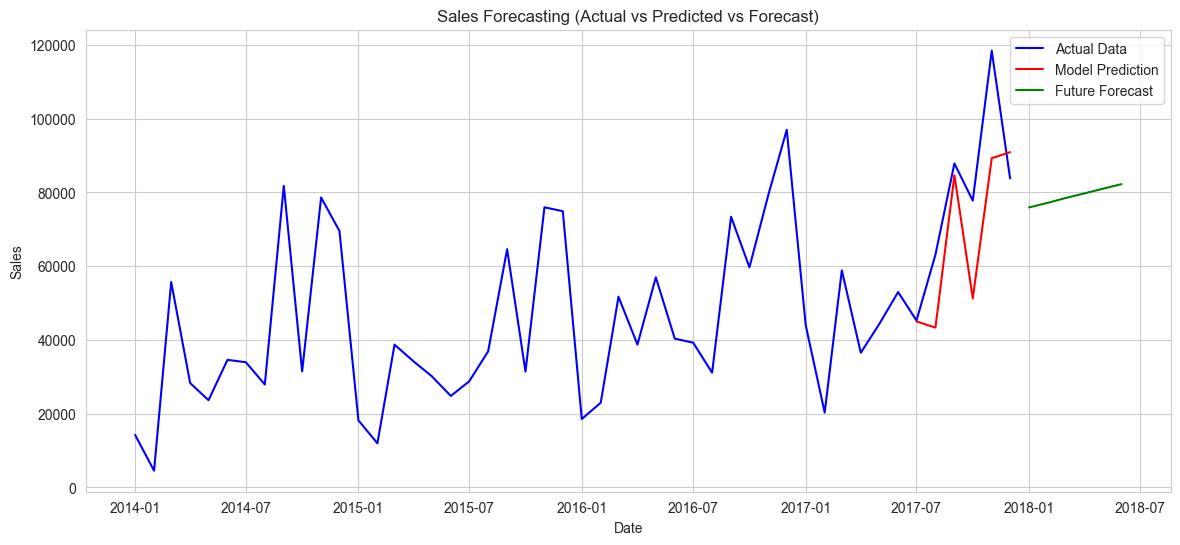

In [36]:
plt.figure(figsize=(14,6))

# Plot full actual data
plt.plot(monthly_sales, label='Actual Data', color='blue')

# Plot predictions (test period)
plt.plot(pred, label='Model Prediction', color='red')

# Plot future forecast
plt.plot(forecast, label='Future Forecast', color='green')

plt.title("Sales Forecasting (Actual vs Predicted vs Forecast)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

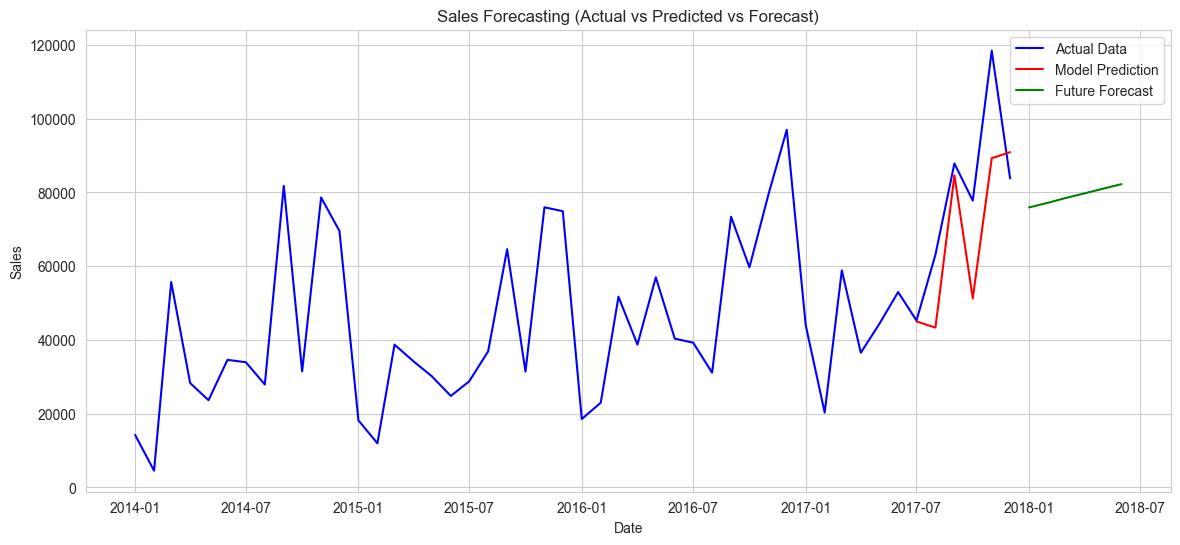

In [40]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14,6))

# Plot everything ON SAME AXIS
ax.plot(monthly_sales, label='Actual Data', color='blue')
ax.plot(pred, label='Model Prediction', color='red')
ax.plot(forecast, label='Future Forecast', color='green')

ax.set_title("Sales Forecasting (Actual vs Predicted vs Forecast)")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()

# 🔥 SAVE CORRECT FIGURE
fig.savefig("output/final_forecast.png")

plt.show()